In [4]:
import sys
from pathlib import Path

ROOT = Path().resolve()
sys.path.append(str(ROOT / "solution-guidance"))
import cslib

In [5]:
train_dir = ROOT / "cs-train"
prod_dir  = ROOT / "cs-production"

train_files = sorted(train_dir.glob("*.json"))
prod_files  = sorted(prod_dir.glob("*.json"))

len(train_files), len(prod_files), train_files[0].name

(21, 5, 'invoices-2017-11.json')

In [6]:
[f for f in dir(cslib) if "data" in f.lower() or "load" in f.lower() or "ingest" in f.lower()]

['__loader__', 'fetch_data']

In [7]:
help(cslib)

Help on module cslib:

NAME
    cslib - collection of functions for the final case study solution

FUNCTIONS
    convert_to_ts(df_orig, country=None)
        given the original DataFrame (fetch_data())
        return a numerically indexed time-series DataFrame 
        by aggregating over each day
    
    engineer_features(df, training=True)
        for any given day the target becomes the sum of the next days revenue
        for that day we engineer several features that help predict the summed revenue
        
        the 'training' flag will trim data that should not be used for training
        when set to false all data will be returned
    
    fetch_data(data_dir)
        laod all json formatted files into a dataframe
    
    fetch_ts(data_dir, clean=False)
        convenience function to read in new data
        uses csv to load quickly
        use clean=True when you want to re-create the files

DATA
    COLORS = ['darkorange', 'royalblue', 'slategrey']

FILE
    /Users/nsoh

In [8]:
mkdir -p src notebooks

In [12]:
from pathlib import Path
import sys

# If notebook is in notebooks/, add repo root + src to path
REPO = Path().resolve().parents[0]  # if notebook is in repo root
if (REPO / "cs-train").exists() is False:
    REPO = Path().resolve().parents[1]  # if notebook is in notebooks/

sys.path.append(str(REPO / "src"))

from ingest import load_raw, to_timeseries, make_features

ModuleNotFoundError: No module named 'ingest'

In [11]:
from pathlib import Path
Path().resolve(), list(Path().resolve().iterdir())

(PosixPath('/Users/nsohal/Documents/ai-workflow-capstone'),
 [PosixPath('/Users/nsohal/Documents/ai-workflow-capstone/solution-guidance'),
  PosixPath('/Users/nsohal/Documents/ai-workflow-capstone/cs-train'),
  PosixPath('/Users/nsohal/Documents/ai-workflow-capstone/README.md'),
  PosixPath('/Users/nsohal/Documents/ai-workflow-capstone/.ipynb_checkpoints'),
  PosixPath('/Users/nsohal/Documents/ai-workflow-capstone/.git'),
  PosixPath('/Users/nsohal/Documents/ai-workflow-capstone/notebooks'),
  PosixPath('/Users/nsohal/Documents/ai-workflow-capstone/cs-production'),
  PosixPath('/Users/nsohal/Documents/ai-workflow-capstone/src')])

In [13]:
from pathlib import Path
import sys

# If notebook is in notebooks/, add repo root + src to path
REPO = Path().resolve().parents[0]  # if notebook is in repo root
if (REPO / "cs-train").exists() is False:
    REPO = Path().resolve().parents[1]  # if notebook is in notebooks/

sys.path.append(str(REPO / "src"))

from ingest import load_raw, to_timeseries, make_features

ModuleNotFoundError: No module named 'ingest'

In [14]:
from pathlib import Path
import sys

# Find repo root dynamically
current = Path().resolve()

if (current / "cs-train").exists():
    REPO = current
elif (current.parent / "cs-train").exists():
    REPO = current.parent
else:
    raise RuntimeError("Could not locate repo root")

# Add src to Python path
sys.path.insert(0, str(REPO / "src"))

from ingest import load_raw, to_timeseries, make_features

In [15]:
df_train_raw = load_raw(REPO / "cs-train")
df_train_raw.shape

(815011, 10)

In [16]:
ts_all = to_timeseries(df_train_raw)
ts_all.head()

,date,purchases,unique_invoices,unique_streams,total_views,year_month,revenue
0,2017-11-01,0,0,0,0,2017-11,0.0
1,2017-11-02,0,0,0,0,2017-11,0.0
2,2017-11-03,0,0,0,0,2017-11,0.0
3,2017-11-04,0,0,0,0,2017-11,0.0
4,2017-11-05,0,0,0,0,2017-11,0.0


In [17]:
ts_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   date             607 non-null    datetime64[s]
 1   purchases        607 non-null    int64        
 2   unique_invoices  607 non-null    int64        
 3   unique_streams   607 non-null    int64        
 4   total_views      607 non-null    int64        
 5   year_month       607 non-null    str          
 6   revenue          607 non-null    float64      
dtypes: datetime64[s](1), float64(1), int64(4), str(1)
memory usage: 33.3 KB


In [18]:
df_feat = make_features(ts_all, training=True)
df_feat.head()
df_feat.shape

AttributeError: module 'numpy' has no attribute 'in1d'

In [19]:
import numpy as np

# Patch for newer numpy versions where in1d is missing/deprecated
if not hasattr(np, "in1d"):
    np.in1d = np.isin

In [20]:
df_feat = make_features(ts_all, training=True)
df_feat.head(), df_feat.shape

AttributeError: 'tuple' object has no attribute 'head'

In [21]:
df_feat.head()

AttributeError: 'tuple' object has no attribute 'head'

In [22]:
type(df_feat)

tuple

In [23]:
df_feat, target = make_features(ts_all, training=True)

ValueError: too many values to unpack (expected 2)

In [24]:
result = make_features(ts_all, training=True)
type(result)

tuple

In [25]:
len(result)

3

In [26]:
for i, part in enumerate(result):
    print(i, type(part))

0 <class 'pandas.DataFrame'>
1 <class 'numpy.ndarray'>
2 <class 'numpy.ndarray'>


In [27]:
result = make_features(ts_all, training=True)

df_feat = result[0]          # first item
rest   = result[1:]          # everything else

df_feat.head(), df_feat.shape, len(rest)

(   previous_7  previous_14  previous_28  previous_70  previous_year  \
 0    14450.54     14450.54     14450.54     14450.54            0.0   
 1    27862.50     27862.50     27862.50     27862.50            0.0   
 2    41152.75     41152.75     41152.75     41152.75            0.0   
 3    50840.03     50840.03     50840.03     50840.03            0.0   
 4    52283.29     52283.29     52283.29     52283.29            0.0   
 
    recent_invoices  recent_views  
 0         5.928571    537.392857  
 1        10.310345   1007.103448  
 2        14.966667   1499.066667  
 3        18.533333   1916.533333  
 4        19.600000   2026.966667  ,
 (549, 7),
 2)

In [28]:
df_feat.columns

Index(['previous_7', 'previous_14', 'previous_28', 'previous_70',
       'previous_year', 'recent_invoices', 'recent_views'],
      dtype='str')

In [29]:
df_feat = make_features(ts_all, training=True)
df_feat.head()
df_feat.shape

AttributeError: 'tuple' object has no attribute 'head'

In [30]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ts_all.index, ts_all["y"])
plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

KeyError: 'y'

<Figure size 640x480 with 0 Axes>

In [31]:
ts_all.head()

,date,purchases,unique_invoices,unique_streams,total_views,year_month,revenue
0,2017-11-01,0,0,0,0,2017-11,0.0
1,2017-11-02,0,0,0,0,2017-11,0.0
2,2017-11-03,0,0,0,0,2017-11,0.0
3,2017-11-04,0,0,0,0,2017-11,0.0
4,2017-11-05,0,0,0,0,2017-11,0.0


Index(['date', 'purchases', 'unique_invoices', 'unique_streams', 'total_views',
       'year_month', 'revenue'],
      dtype='str')


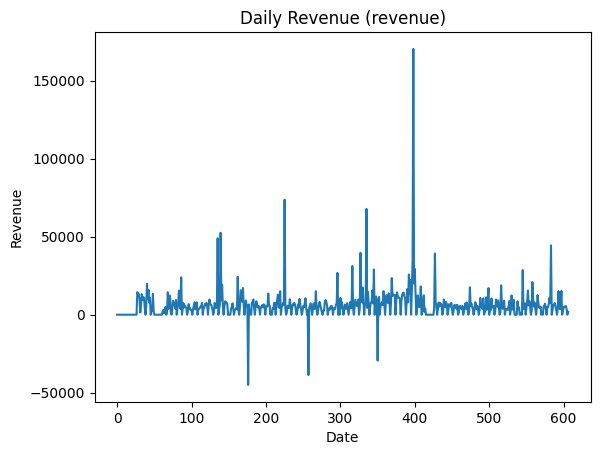

In [32]:
import matplotlib.pyplot as plt

print(ts_all.columns)

# pick revenue column safely
if "y" in ts_all.columns:
    ycol = "y"
elif "revenue" in ts_all.columns:
    ycol = "revenue"
else:
    # fallback: first numeric column
    ycol = ts_all.select_dtypes("number").columns[0]

plt.figure()
plt.plot(ts_all.index, ts_all[ycol])
plt.title(f"Daily Revenue ({ycol})")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [33]:
result = make_features(ts_all, training=True)
type(result), len(result)

(tuple, 3)

In [34]:
for i, part in enumerate(result):
    print(i, type(part), getattr(part, "shape", None))

0 <class 'pandas.DataFrame'> (549, 7)
1 <class 'numpy.ndarray'> (549,)
2 <class 'numpy.ndarray'> (549,)


In [35]:
df_feat = result[0]
df_feat.head(), df_feat.shape

(   previous_7  previous_14  previous_28  previous_70  previous_year  \
 0    14450.54     14450.54     14450.54     14450.54            0.0   
 1    27862.50     27862.50     27862.50     27862.50            0.0   
 2    41152.75     41152.75     41152.75     41152.75            0.0   
 3    50840.03     50840.03     50840.03     50840.03            0.0   
 4    52283.29     52283.29     52283.29     52283.29            0.0   
 
    recent_invoices  recent_views  
 0         5.928571    537.392857  
 1        10.310345   1007.103448  
 2        14.966667   1499.066667  
 3        18.533333   1916.533333  
 4        19.600000   2026.966667  ,
 (549, 7))